# Basin IKE Comparison: Violin Plot

Two-panel violin plot of storm-level IKE by basin (average IKE per TC, maximum
lifetime IKE). 


## Paths

See the repo README ("Setting IBTRACS_PATH / IKE_OUTPUT_DIR") for why these are set here rather than relying on a shell-level `export`.

In [1]:
import os
os.environ["IBTRACS_PATH"] = "/home/sydney.e.walters/IBTrACS"
os.environ["IKE_OUTPUT_DIR"] = "/home/sydney.e.walters/IBTrACS_Manuscript_Figures"


## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ike_climatology import config
from ike_climatology.ibtracs_io import load_master_dataframe
from ike_climatology.style import BASIN_COLORS, DESIRED_BASIN_ORDER


## Data extraction

Uses `load_master_dataframe`'s defaults (`apply_quality_filters=True`): a
storm must reach 34+ kt and produce positive IKE to be included.

In [3]:
master_df = load_master_dataframe(
    basins=config.BASINS_TO_ANALYZE,
    file_map=config.IBTRACS_FILE_MAP,
    basin_codes=config.IBTRACS_BASIN_CODES,
    start_year=config.START_YEAR,
    end_year=config.END_YEAR,
    land_interaction_threshold_km=config.LAND_INTERACTION_THRESHOLD_KM,
)

if master_df.empty:
    raise RuntimeError("No processable storm data found -- check IBTRACS_PATH.")

valid_ike_master = master_df.dropna(subset=["total_ike_tj"]).copy()
valid_ike_master = valid_ike_master[valid_ike_master["total_ike_tj"] > 0]

storm_level_df = valid_ike_master.groupby(
    ["basin", "storm_year", "storm_id", "storm_name"]
).agg(
    storm_time_avg_ike=("total_ike_tj", "mean"),
    peak_ike=("total_ike_tj", "max"),
    total_ike_tj=("total_ike_tj", "sum"),
).reset_index()

print(f"{len(storm_level_df)} storms across {storm_level_df['basin'].nunique()} basins.")


--- Starting Initial Data Loading and Processing for All Basins ---
    - Loading IBTrACS data for North Atlantic (2004-2024)
        Found 380 storms in file.
        - Filtered out 2 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for East Pacific (2004-2024)
        Found 497 storms in file.
        - Filtered out 79 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for West Pacific (2004-2024)
        Found 622 storms in file.
        - Filtered out 16 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for North Indian (2004-2024)
        Found 220 storms in file.
        - Filtered out 13 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for South Indian (2004-2024)
        Found 367 storms in file.
        - Filtered out 22 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data

## Figure: violin plot of IKE by basin

/tmp/ipykernel_1074937/1299873287.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1074937/1299873287.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


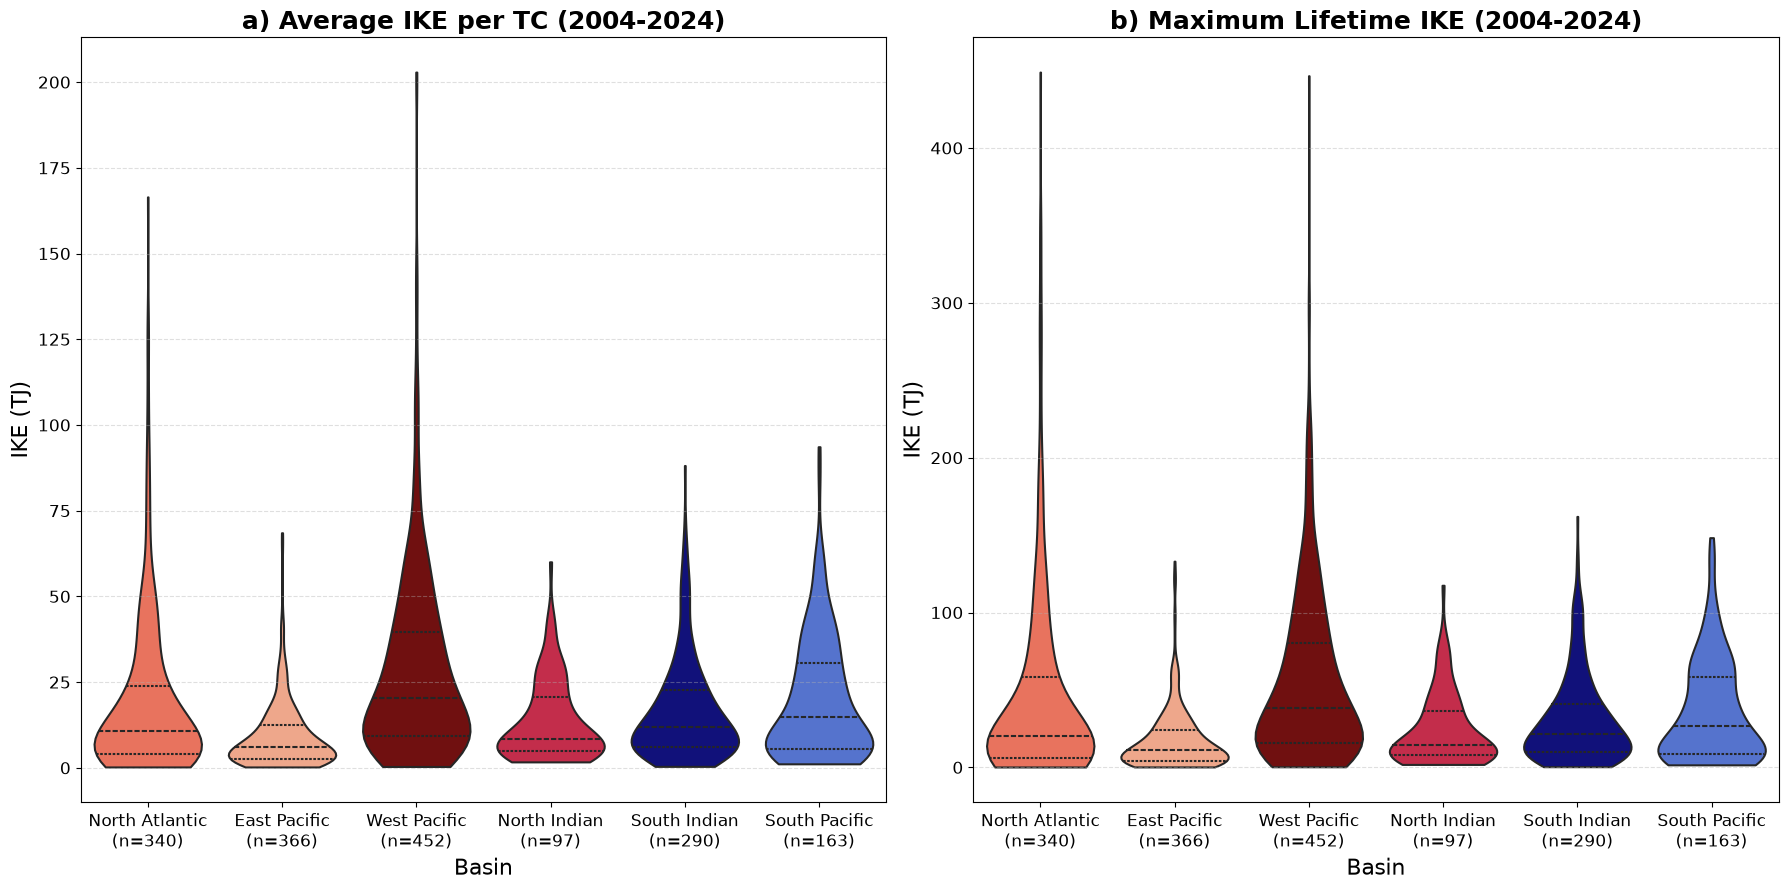

In [4]:
basin_counts = storm_level_df["basin"].value_counts()
xticklabels = [f"{b}\n(n={basin_counts.get(b, 0)})" for b in DESIRED_BASIN_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

metrics = [
    ("storm_time_avg_ike", "a) Average IKE per TC"),
    ("peak_ike", "b) Maximum Lifetime IKE"),
]

years = storm_level_df["storm_year"].unique()
year_str = f"({years.min()}-{years.max()})"

for i, (col_name, label) in enumerate(metrics):
    ax = axes[i]
    sns.violinplot(
        x="basin", y=col_name, data=storm_level_df, ax=ax,
        palette=BASIN_COLORS, order=DESIRED_BASIN_ORDER,
        density_norm="width", inner="quartile", linewidth=1.5, cut=0,
    )
    ax.set_title(f"{label} {year_str}", fontsize=18, weight="bold")
    ax.set_xlabel("Basin", fontsize=16)
    ax.set_ylabel("IKE (TJ)", fontsize=16)
    ax.set_yscale("linear")
    ax.set_xticks(range(len(DESIRED_BASIN_ORDER)))
    ax.set_xticklabels(xticklabels)
    ax.grid(True, linestyle="--", alpha=0.4, axis="y")
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)

plt.tight_layout()
os.makedirs(config.BASE_OUTPUT_DIR, exist_ok=True)
plt.savefig(os.path.join(config.BASE_OUTPUT_DIR, "climatology_violin_comparison.png"),
            dpi=300, bbox_inches="tight")
plt.show()
